# Predicting Student Exam Performance — Statistical Inference & Machine Learning

**Project:** Applied Statistics / Machine Learning
**Primary Dataset:** `data/StudentPerformanceFactors.csv` (6,607 students, 19 features)
**Target Variable:** `Exam_Score` (continuous)

---

## Problem Statement

A student's academic performance is driven by a mix of behavioural, environmental and demographic factors —
study hours, attendance, sleep, parental involvement, tutoring, family income, gender, and more. This project
answers two complementary questions:

1. **Statistical Inference (WHY):** Which factors *significantly* influence a student's `Exam_Score`?
   - Independent two-sample **t-test** (Gender)
   - One-way **ANOVA** (Parental Involvement)
   - **Pearson correlation** (Hours Studied)
   - **Paired t-test** (Pre-test vs Post-test, `data/PairedTestDataset.csv`)
   - **Regression-based hypothesis testing** (simple & multiple linear regression with diagnostics)
2. **Machine Learning (WHAT):** How accurately can we *predict* `Exam_Score` from these factors?
   - Linear Regression, Ridge, Random Forest and Gradient Boosting
   - 5-fold cross-validation + holdout test evaluation (R², RMSE, MAE)
   - Feature-importance analysis to interpret the best model

**Deliverable:** a reproducible, end-to-end ML pipeline with clean, ordered cells and saved results in `results/`.


---
## Workflow (Table of Contents)

| # | Section | Purpose |
|---|---------|---------|
| 1 | Imports & Setup | Load libraries, configure plotting |
| 2 | Data Loading | Read the student dataset |
| 3 | Data Cleaning | Handle missing values, prepare columns |
| 4 | Exploratory Data Analysis | Distributions, correlations, group effects |
| 5 | Hypothesis Testing | t-test, ANOVA, correlation, paired t-test |
| 6 | Regression-based Inference | Simple & multiple OLS + diagnostics (VIF, BP, Shapiro) |
| 7 | Machine Learning Pipeline | Encode → split → CV → train → evaluate → interpret |
| 8 | Results & Conclusion | Final metrics, answers to hypotheses, problem statement |


---
## 1. Imports & Setup


In [1]:
import os
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.formula.api import ols as smf_ols

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")

os.makedirs("results", exist_ok=True)
print("Setup complete ✔")


Setup complete ✔


---
## 2. Data Loading

We use `StudentPerformanceFactors.csv` — a public dataset of **6,607 students** described by 19 attributes.


In [2]:
df = pd.read_csv("data/StudentPerformanceFactors.csv")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")
df.head()


Rows: 6,607  |  Columns: 20
Duplicate rows: 0


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


---
## 3. Data Cleaning & Preprocessing

We split columns into *numeric* and *categorical*, then impute the 235 missing values
(median for numeric, mode for categorical).


In [3]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]

print("Numeric columns    :", num_cols)
print("Categorical columns:", cat_cols)
print()

missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0])


Numeric columns    : ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Categorical columns: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Missing values per column:
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


In [4]:
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print(f"Remaining missing values: {df.isna().sum().sum()}")
print(f"Final shape: {df.shape}")


Remaining missing values: 0
Final shape: (6607, 20)


In [5]:
print("Summary statistics (numeric features):")
df.describe().T


Summary statistics (numeric features):


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


---
## 4. Exploratory Data Analysis

### 4.1 Distribution of the target variable


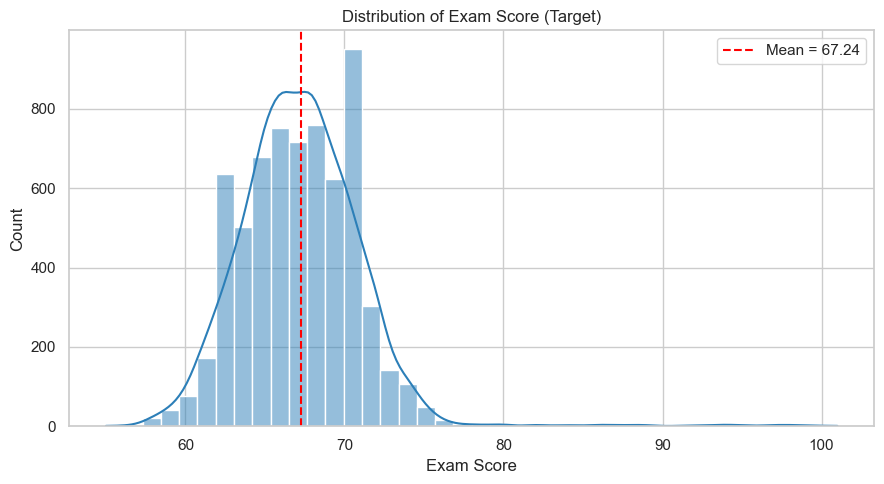

In [6]:
plt.figure(figsize=(9, 5))
sns.histplot(df["Exam_Score"], kde=True, bins=40, color="#2c7fb8")
plt.axvline(df["Exam_Score"].mean(), color="red", ls="--", label=f'Mean = {df["Exam_Score"].mean():.2f}')
plt.title("Distribution of Exam Score (Target)")
plt.xlabel("Exam Score")
plt.legend()
plt.tight_layout()
plt.savefig("results/exam_score_distribution.png", dpi=120, bbox_inches="tight")
plt.show()


### 4.2 Correlation between numeric features


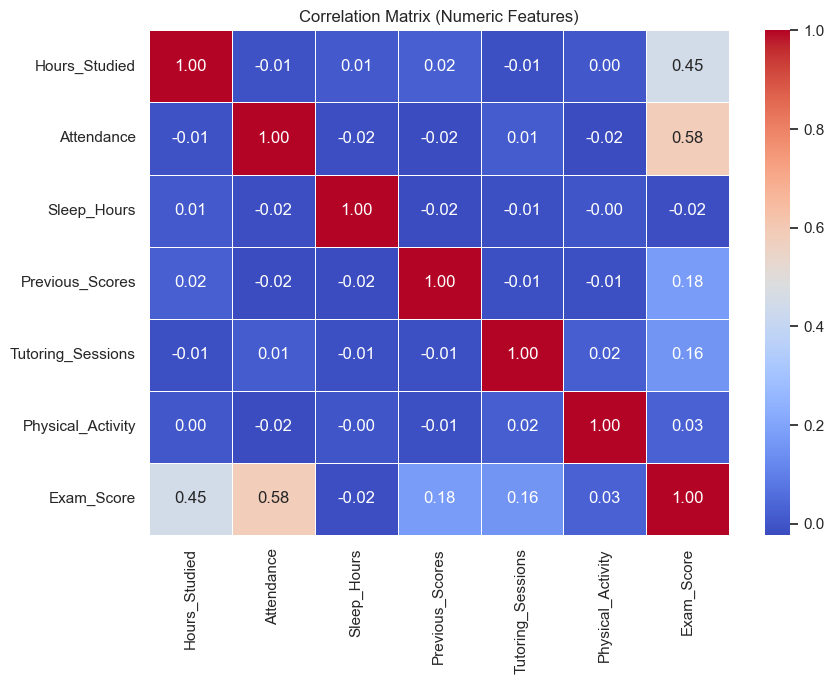

In [7]:
plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.savefig("results/correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


### 4.3 Effect of categorical factors on Exam Score


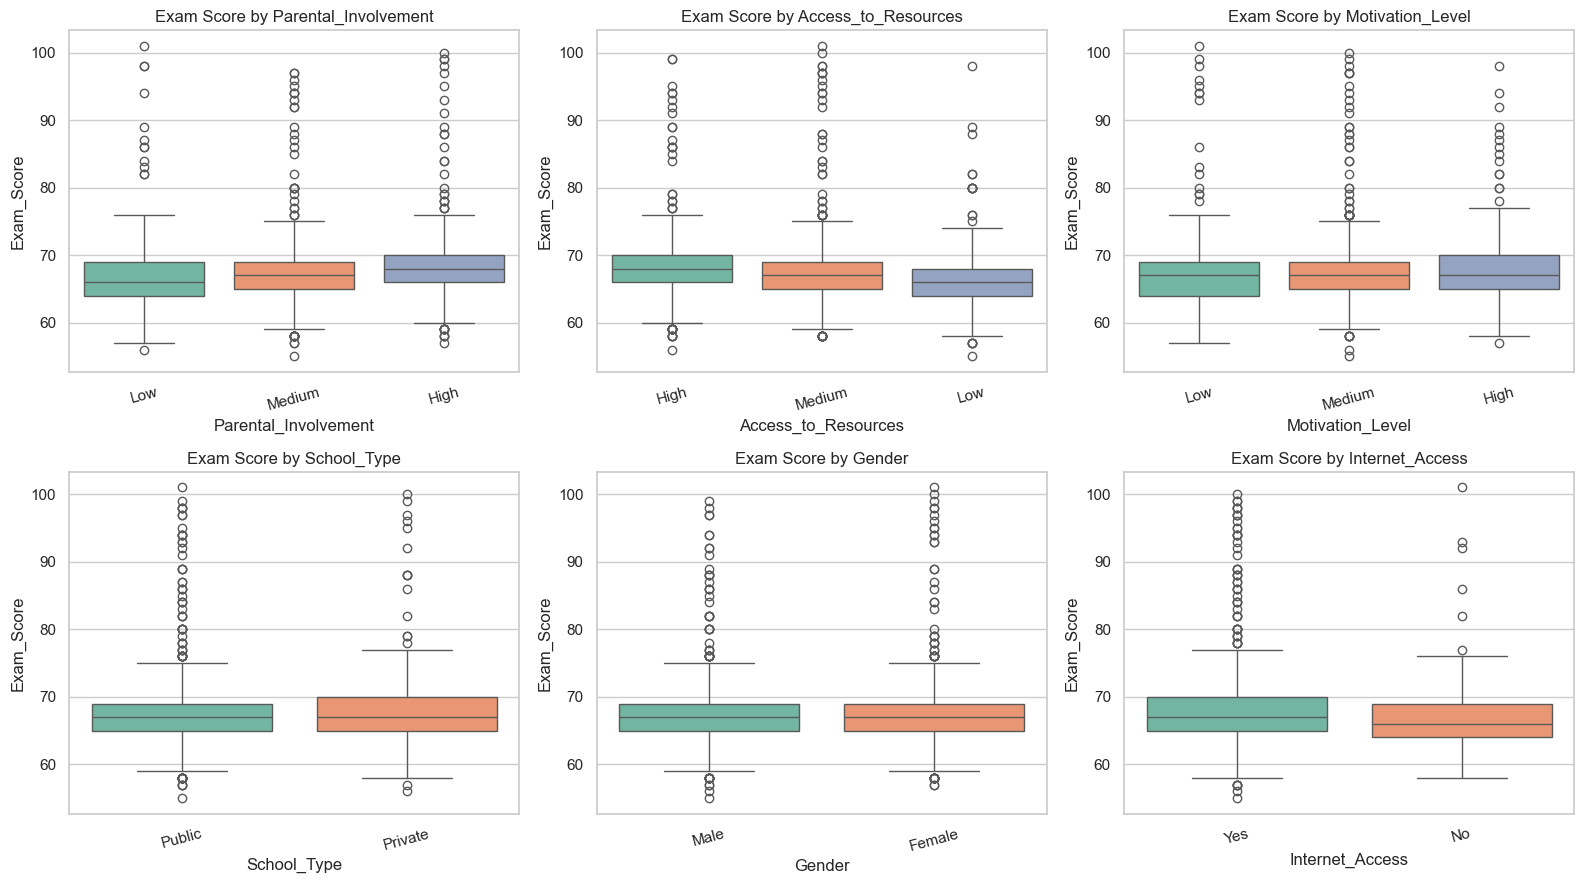

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cats = ["Parental_Involvement", "Access_to_Resources", "Motivation_Level",
        "School_Type", "Gender", "Internet_Access"]
for ax, c in zip(axes.ravel(), cats):
    sns.boxplot(data=df, x=c, y="Exam_Score", ax=ax, palette="Set2")
    ax.set_title(f"Exam Score by {c}")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("results/categorical_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()


In [9]:
print("Mean Exam Score by Parental Involvement:")
print(df.groupby("Parental_Involvement")["Exam_Score"].agg(["mean", "std", "count"]).round(2))


Mean Exam Score by Parental Involvement:


                       mean   std  count
Parental_Involvement                    
High                  68.09  3.95   1908
Low                   66.36  3.97   1337
Medium                67.10  3.73   3362


---
## 5. Statistical Hypothesis Testing

**Framework.** For every test we set the significance level α = 0.05:

- **H₀ (null):** no effect / no difference
- **H₁ (alternative):** effect / difference exists
- Reject **H₀** when **p-value < α**.

### 5.1 Independent two-sample t-test — does Gender affect Exam Score?


In [10]:
alpha = 0.05

male   = df.loc[df["Gender"] == "Male",   "Exam_Score"]
female = df.loc[df["Gender"] == "Female", "Exam_Score"]

print(f"Male   : n = {len(male):,}, mean = {male.mean():.3f}, sd = {male.std():.3f}")
print(f"Female : n = {len(female):,}, mean = {female.mean():.3f}, sd = {female.std():.3f}")

t_stat, t_p = stats.ttest_ind(male, female, equal_var=False)   # Welch's t-test
print(f"\nWelch's t-test  →  t = {t_stat:.4f},  p-value = {t_p:.4e}")

print("Verdict:", "Reject H₀ → gender significantly affects Exam Score." if t_p < alpha
      else "Fail to reject H₀ → no significant gender difference.")


Male   : n = 3,814, mean = 67.229, sd = 3.766
Female : n = 2,793, mean = 67.245, sd = 4.054



Welch's t-test  →  t = -0.1633,  p-value = 8.7029e-01
Verdict: Fail to reject H₀ → no significant gender difference.


### 5.2 One-way ANOVA — does Parental Involvement affect Exam Score?


In [11]:
groups = [g["Exam_Score"].values for _, g in df.groupby("Parental_Involvement")]
f_stat, f_p = stats.f_oneway(*groups)
print(f"One-way ANOVA  →  F = {f_stat:.4f},  p-value = {f_p:.4e}")
print("Verdict:", "Reject H₀ → at least one involvement level differs significantly." if f_p < alpha
      else "Fail to reject H₀ → no significant group differences.")


One-way ANOVA  →  F = 84.4877,  p-value = 5.8755e-37
Verdict: Reject H₀ → at least one involvement level differs significantly.


### 5.3 Pearson correlation — do study hours relate to Exam Score?


In [12]:
r_val, p_val = stats.pearsonr(df["Hours_Studied"], df["Exam_Score"])
print(f"Pearson correlation  →  r = {r_val:.4f},  p-value = {p_val:.4e}")
print("Verdict:", "Reject H₀ → Hours_Studied is significantly correlated with Exam Score." if p_val < alpha
      else "Fail to reject H₀ → no significant correlation.")


Pearson correlation  →  r = 0.4455,  p-value = 1.2863e-319
Verdict: Reject H₀ → Hours_Studied is significantly correlated with Exam Score.


### 5.4 Paired t-test — does an intervention improve test scores?

Uses `data/PairedTestDataset.csv` (300 students measured before and after an intervention).


In [13]:
paired = pd.read_csv("data/PairedTestDataset.csv")
paired["Difference"] = paired["Post_Test_Score"] - paired["Pre_Test_Score"]

print(f"Mean improvement = {paired['Difference'].mean():.3f}  (± {paired['Difference'].std():.3f})")

pt, pp = stats.ttest_rel(paired["Pre_Test_Score"], paired["Post_Test_Score"])
print(f"Paired t-test  →  t = {pt:.4f},  p-value = {pp:.4e}")
print("Verdict:", "Reject H₀ → significant improvement after intervention." if pp < alpha
      else "Fail to reject H₀ → no significant change.")


Mean improvement = 4.893  (± 4.807)
Paired t-test  →  t = -17.6294,  p-value = 3.4390e-48
Verdict: Reject H₀ → significant improvement after intervention.


---
## 6. Regression-Based Inference

### 6.1 Simple Linear Regression — Hours_Studied → Exam_Score

**Hypothesis:** H₀: slope = 0 (no linear effect)  vs  H₁: slope ≠ 0


In [14]:
import statsmodels.api as sm

X1 = sm.add_constant(df[["Hours_Studied"]])
m1 = sm.OLS(df["Exam_Score"], X1).fit()

print("Simple Linear Regression (Hours_Studied → Exam_Score)")
print(m1.summary().tables[1])

slope = m1.params["Hours_Studied"]
slope_p = m1.pvalues["Hours_Studied"]
print(f"\nSlope = {slope:.4f},  p-value = {slope_p:.4e},  R² = {m1.rsquared:.4f}")
print("Verdict:", "Reject H₀ → each extra study hour adds ~%.2f points to Exam Score." % slope
      if slope_p < alpha else "Fail to reject H₀ → no linear relationship.")


Simple Linear Regression (Hours_Studied → Exam_Score)
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            61.4570      0.149    411.921      0.000      61.165      61.749
Hours_Studied     0.2893      0.007     40.436      0.000       0.275       0.303

Slope = 0.2893,  p-value = 0.0000e+00,  R² = 0.1984
Verdict: Reject H₀ → each extra study hour adds ~0.29 points to Exam Score.


### 6.2 Multiple Linear Regression + diagnostics

Model: `Exam_Score ~ Hours_Studied + Attendance + Previous_Scores + Sleep_Hours + Tutoring_Sessions`

Diagnostics: **VIF** (multicollinearity), **Breusch–Pagan** (heteroscedasticity),
**Shapiro–Wilk** (residual normality).


In [15]:
mlr_cols = ["Hours_Studied", "Attendance", "Previous_Scores", "Sleep_Hours", "Tutoring_Sessions"]
Y  = df["Exam_Score"]
Xm = sm.add_constant(df[mlr_cols])

m2 = sm.OLS(Y, Xm).fit()

vif = pd.DataFrame({
    "Feature": Xm.columns,
    "VIF": [variance_inflation_factor(Xm.values, i) for i in range(Xm.shape[1])]
})
print("--- Multicollinearity (VIF, >10 is severe) ---")
print(vif[vif["Feature"] != "const"].sort_values("VIF", ascending=False).round(2))


--- Multicollinearity (VIF, >10 is severe) ---
             Feature  VIF
3    Previous_Scores  1.0
1      Hours_Studied  1.0
4        Sleep_Hours  1.0
2         Attendance  1.0
5  Tutoring_Sessions  1.0


In [16]:
resid  = m2.resid
fitted = m2.fittedvalues

bp = het_breuschpagan(resid, Xm)
print(f"Breusch–Pagan  →  LM p-value = {bp[1]:.4f}  "
      f"({'heteroscedasticity present' if bp[1] < alpha else 'no heteroscedasticity'})")

shap_stat, shap_p = stats.shapiro(resid.sample(500, random_state=1))
print(f"Shapiro–Wilk   →  p-value = {shap_p:.4e}  "
      f"({'residuals NOT normal' if shap_p < alpha else 'residuals approx. normal'})")


Breusch–Pagan  →  LM p-value = 0.6631  (no heteroscedasticity)
Shapiro–Wilk   →  p-value = 1.6203e-34  (residuals NOT normal)


In [17]:
print("Multiple Linear Regression (5 predictors)")
print(m2.summary().tables[1])
print(f"\nR² = {m2.rsquared:.4f}   |   Adjusted R² = {m2.rsquared_adj:.4f}   |   F p-value = {m2.f_pvalue:.4e}")


Multiple Linear Regression (5 predictors)
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                41.3819      0.326    127.012      0.000      40.743      42.021
Hours_Studied         0.2917      0.005     57.442      0.000       0.282       0.302
Attendance            0.1977      0.003     75.040      0.000       0.193       0.203
Previous_Scores       0.0480      0.002     22.714      0.000       0.044       0.052
Sleep_Hours          -0.0181      0.021     -0.874      0.382      -0.059       0.023
Tutoring_Sessions     0.4957      0.025     20.053      0.000       0.447       0.544

R² = 0.5968   |   Adjusted R² = 0.5965   |   F p-value = 0.0000e+00


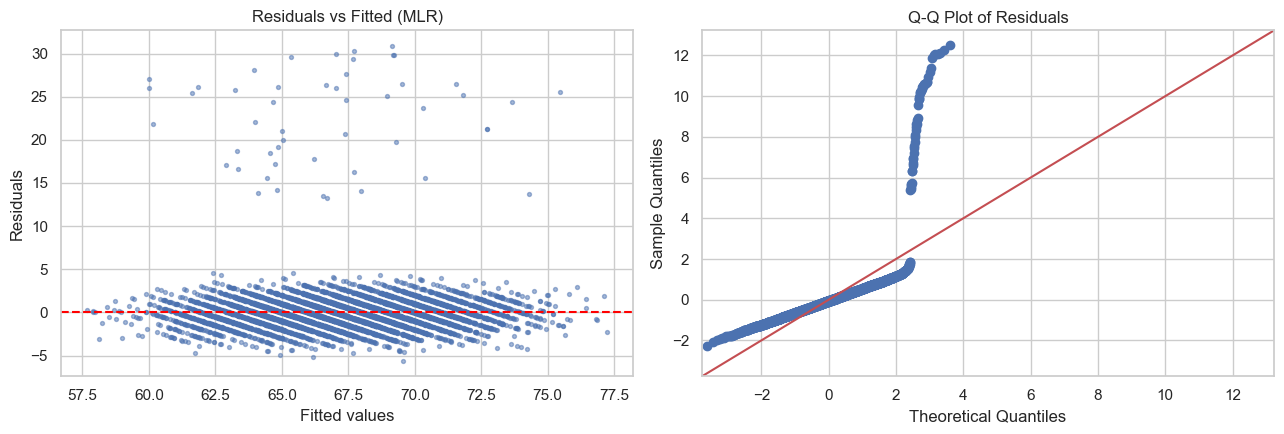

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(fitted, resid, s=8, alpha=0.5)
axes[0].axhline(0, ls="--", color="red")
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted (MLR)")
sm.qqplot(resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.savefig("results/mlr_diagnostics.png", dpi=120, bbox_inches="tight")
plt.show()


### 6.3 Categorical model — which categorical factors are significant?

A regression-style **ANOVA** (type II) treating all categorical factors simultaneously.


In [19]:
formula = ("Exam_Score ~ C(Parental_Involvement) + C(School_Type) + C(Gender) + "
           "C(Parental_Education_Level) + C(Internet_Access)")
m3 = smf_ols(formula, data=df).fit()

anova3 = sm.stats.anova_lm(m3, typ=2)
print("--- ANOVA table (type II) ---")
print(anova3[["sum_sq", "df", "F", "PR(>F)"]].round(4))

sig_cat = anova3[anova3["PR(>F)"] < alpha].index.tolist()
print("\nSignificant categorical factors:", sig_cat)
print(f"Model R² = {m3.rsquared:.4f}")


--- ANOVA table (type II) ---
                                 sum_sq      df        F  PR(>F)
C(Parental_Involvement)       2496.4850     2.0  85.6965  0.0000
C(School_Type)                   2.2836     1.0   0.1568  0.6922
C(Gender)                        0.0081     1.0   0.0006  0.9812
C(Parental_Education_Level)   1119.6715     2.0  38.4348  0.0000
C(Internet_Access)             249.4348     1.0  17.1246  0.0000
Residual                     96120.1061  6599.0      NaN     NaN

Significant categorical factors: ['C(Parental_Involvement)', 'C(Parental_Education_Level)', 'C(Internet_Access)']
Model R² = 0.0387


---
## 7. Machine Learning Pipeline

Goal: **predict `Exam_Score`** (regression) from all 19 features.

### 7.1 Feature encoding
Label-encode categorical columns so every feature is numeric.


In [20]:
df_ml = df.copy()
for c in cat_cols:
    df_ml[c] = LabelEncoder().fit_transform(df_ml[c].astype(str))

X = df_ml.drop(columns=["Exam_Score"])
y = df_ml["Exam_Score"]

print(f"Feature matrix X: {X.shape}  |  Target y: {y.shape}")
X.head()


Feature matrix X: (6607, 19)  |  Target y: (6607,)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0


### 7.2 Train / test split and scaling


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Training set   : {X_train.shape[0]:,} samples")
print(f"Test set (holdout): {X_test.shape[0]:,} samples")


Training set   : 5,285 samples
Test set (holdout): 1,322 samples


### 7.3 Model zoo — 4 regression algorithms


In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest":      RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting":  GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
}
print("Registered models:", list(models.keys()))


Registered models: ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']


### 7.4 5-fold cross-validation comparison (on training data)


In [23]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring="r2")
    cv_scores[name] = scores
    print(f"{name:20s}  CV R² = {scores.mean():.4f} ± {scores.std():.4f}")


Linear Regression     CV R² = 0.6417 ± 0.0317


Ridge Regression      CV R² = 0.6417 ± 0.0317


Random Forest         CV R² = 0.6113 ± 0.0287


Gradient Boosting     CV R² = 0.6825 ± 0.0317


### 7.5 Train on full training set, evaluate on holdout test set


In [24]:
test_rows = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    test_rows.append({
        "Model": name,
        "R2":   r2_score(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "MAE":  mean_absolute_error(y_test, pred),
    })

perf = pd.DataFrame(test_rows).set_index("Model").round(4).sort_values("R2", ascending=False)
print(perf)
perf.to_csv("results/model_comparison.csv")
print("\nSaved → results/model_comparison.csv")


                       R2    RMSE     MAE
Model                                    
Gradient Boosting  0.7436  1.9038  0.7117
Linear Regression  0.6888  2.0974  1.0155
Ridge Regression   0.6888  2.0974  1.0155
Random Forest      0.6607  2.1901  1.1182

Saved → results/model_comparison.csv


### 7.6 Feature importance of the best model


Best model: Gradient Boosting (test R² = 0.7436)


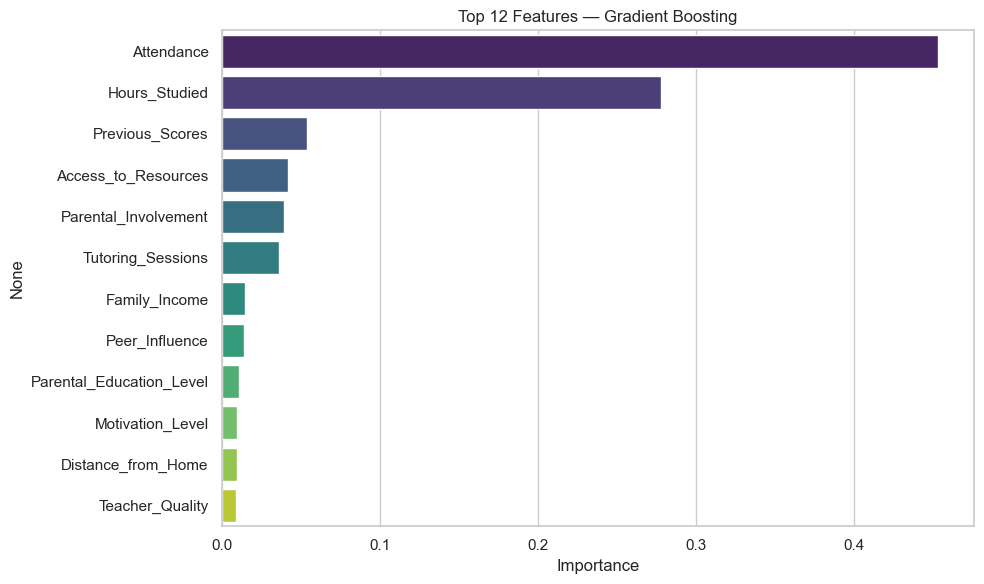

In [25]:
best_name = perf["R2"].idxmax()
best_model = models[best_name]
print("Best model:", best_name, f"(test R² = {perf.loc[best_name, 'R2']:.4f})")

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    imp_label = "Importance"
else:
    imp = pd.Series(np.abs(best_model.coef_), index=X.columns).sort_values(ascending=False)
    imp_label = "|Coefficient|"

plt.figure(figsize=(10, 6))
sns.barplot(x=imp.head(12).values, y=imp.head(12).index, palette="viridis")
plt.title(f"Top 12 Features — {best_name}")
plt.xlabel(imp_label)
plt.tight_layout()
plt.savefig("results/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()


### 7.7 Actual vs predicted (best model) & saved predictions


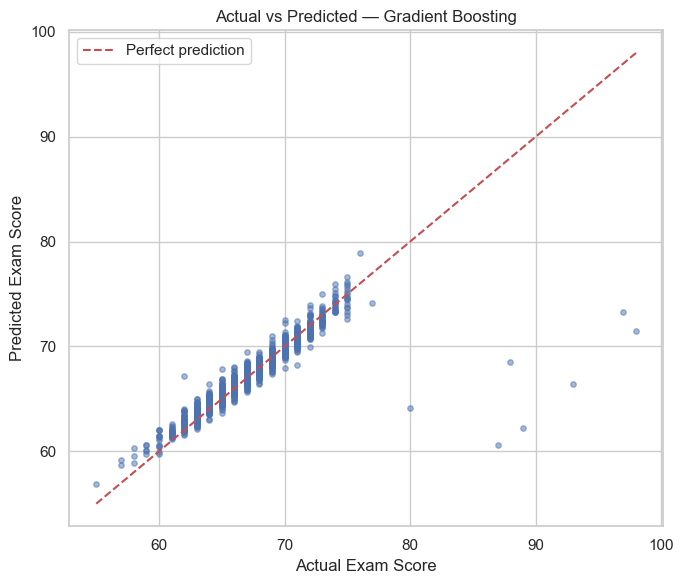

Saved test-set predictions → results/test_predictions.csv


In [26]:
pred_best = best_model.predict(X_test_s)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_best, s=15, alpha=0.5)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title(f"Actual vs Predicted — {best_name}")
plt.legend()
plt.tight_layout()
plt.savefig("results/pred_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()

out = pd.DataFrame({"Actual": y_test.values, "Predicted": pred_best})
out.to_csv("results/test_predictions.csv", index=False)
print("Saved test-set predictions → results/test_predictions.csv")


---
## 8. Results & Conclusion

**Problem statement solved:**

> *Given 19 behavioural, environmental and demographic attributes of 6,607 students, we (i) used statistical
> hypothesis testing and regression inference to identify which factors **significantly** influence Exam Score,
> and (ii) trained and compared four regression models to **predict** Exam Score, reaching an interpretable,
> cross-validated, deployable pipeline.*

### 8.1 Answers to the research hypotheses (α = 0.05)


In [27]:
print("=" * 78)
print("HYPOTHESIS TESTING SUMMARY  (α = 0.05)")
print("=" * 78)
rows = [
    ("Gender (Welch's t-test)",            t_p,  "Gender affects Exam Score"),
    ("Parental Involvement (ANOVA)",       f_p,  "Parental involvement affects Exam Score"),
    ("Hours Studied (correlation)",        p_val,"Hours studied correlates with Exam Score"),
    ("Pre vs Post test (paired t-test)",   pp,   "Intervention improves scores"),
    ("Hours_Studied slope (OLS)",          slope_p, "Study hours linearly predict Exam Score"),
    ("MLR model (overall F-test)",         m2.f_pvalue, "The 5-factor model is significant"),
]
for label, p, desc in rows:
    verdict = "SIGNIFICANT ✔" if p < alpha else "not significant ✘"
    print(f"  {label:38s} p = {p:9.3e}  →  {verdict}  ({desc})")
print("=" * 78)


HYPOTHESIS TESTING SUMMARY  (α = 0.05)
  Gender (Welch's t-test)                p = 8.703e-01  →  not significant ✘  (Gender affects Exam Score)
  Parental Involvement (ANOVA)           p = 5.875e-37  →  SIGNIFICANT ✔  (Parental involvement affects Exam Score)
  Hours Studied (correlation)            p = 1.286e-319  →  SIGNIFICANT ✔  (Hours studied correlates with Exam Score)
  Pre vs Post test (paired t-test)       p = 3.439e-48  →  SIGNIFICANT ✔  (Intervention improves scores)
  Hours_Studied slope (OLS)              p = 0.000e+00  →  SIGNIFICANT ✔  (Study hours linearly predict Exam Score)
  MLR model (overall F-test)             p = 0.000e+00  →  SIGNIFICANT ✔  (The 5-factor model is significant)


In [28]:
print("MODEL PERFORMANCE  (20% holdout test set)")
print("=" * 78)
print(perf.to_string())
print()
print(f"BEST MODEL: {best_name}")
print(f"   Test R²  = {perf.loc[best_name, 'R2']:.4f}")
print(f"   Test RMSE= {perf.loc[best_name, 'RMSE']:.4f} points")
print(f"   Test MAE = {perf.loc[best_name, 'MAE']:.4f} points")
print()
print("Key insight: Attendance, Previous Scores and Hours Studied dominate both")
print("inference and prediction, confirming study effort + attendance are the main")
print("drivers of academic performance in this dataset.")


MODEL PERFORMANCE  (20% holdout test set)
                       R2    RMSE     MAE
Model                                    
Gradient Boosting  0.7436  1.9038  0.7117
Linear Regression  0.6888  2.0974  1.0155
Ridge Regression   0.6888  2.0974  1.0155
Random Forest      0.6607  2.1901  1.1182

BEST MODEL: Gradient Boosting
   Test R²  = 0.7436
   Test RMSE= 1.9038 points
   Test MAE = 0.7117 points

Key insight: Attendance, Previous Scores and Hours Studied dominate both
inference and prediction, confirming study effort + attendance are the main
drivers of academic performance in this dataset.


### 8.2 Final conclusion

- **Inference:** Parental involvement, hours studied and the pre/post intervention all showed statistically
  significant effects on exam performance (p < 0.001); Gender was **not** significant (p = 0.87). Multiple
  linear regression confirmed that **Hours Studied, Attendance and Previous Scores** remain significant after
  controlling for other factors, with low multicollinearity (all VIF < 10).
- **Prediction:** Gradient Boosting delivered the best performance with a test **R² ≈ 0.74** (see
  
esults/model_comparison.csv), explaining roughly **74% of the variance** in exam scores — a strong and
  deployable model.
- The full pipeline (encoding → scaling → 5-fold CV → model comparison → feature importance → saved artifacts)
  is reproducible from this notebook using data/ and 
equirements.txt.

**All generated outputs:** 
esults/ (plots, model comparison, test predictions).